# 01 — Data Exploration

Pulls historical EPL match data (results, corners, cards, closing odds) via `pl_predictor.data.football_data` and sanity-checks the distributions we'll be modeling.

In [1]:
import sys
sys.path.insert(0, '../src')
import warnings; warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
from pl_predictor.data.football_data import load_training_data, default_completed_seasons

seasons = default_completed_seasons()
print(seasons)

Matplotlib is building the font cache; this may take a moment.


['2018-2019', '2019-2020', '2020-2021', '2021-2022', '2022-2023', '2023-2024', '2024-2025', '2025-2026']


In [2]:
df = load_training_data(seasons=seasons)
print(df.shape)
df[['date','team_home','team_away','goals_home','goals_away','hc','ac','hy','ay','b365_h','b365_d','b365_a']].head()

(3040, 186)


,date,team_home,team_away,goals_home,goals_away,hc,ac,hy,ay,b365_h,b365_d,b365_a
0,2018-08-10,Man United,Leicester,2,1,2,5,2,1,1.57,3.9,7.50
1,2018-08-11,Bournemouth,Cardiff,2,0,7,4,1,1,1.90,3.6,4.50
2,2018-08-11,Fulham,Crystal Palace,0,2,5,5,1,2,2.50,3.4,3.00
3,2018-08-11,Huddersfield,Chelsea,0,3,2,5,2,1,6.50,4.0,1.61
4,2018-08-11,Newcastle,Tottenham,1,2,3,5,2,2,3.90,3.5,2.04


## Goals, corners, and cards distributions

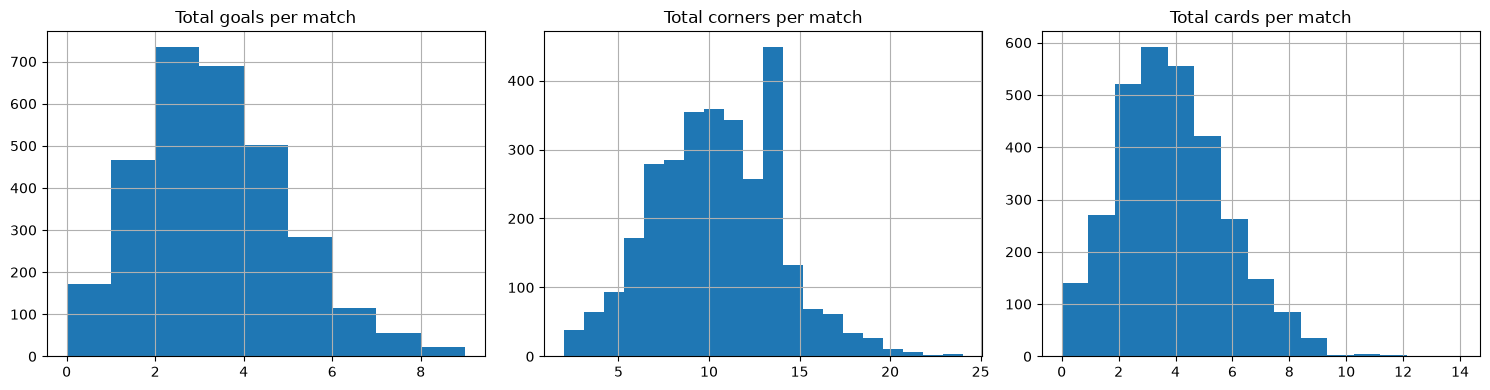

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
(df['goals_home'] + df['goals_away']).hist(bins=range(0, 10), ax=axes[0])
axes[0].set_title('Total goals per match')
(df['hc'] + df['ac']).hist(bins=20, ax=axes[1])
axes[1].set_title('Total corners per match')
(df['hy'] + df['ay'] + df['hr'] + df['ar']).hist(bins=15, ax=axes[2])
axes[2].set_title('Total cards per match')
plt.tight_layout()
plt.show()

## Home advantage — sanity check

EPL home teams should win noticeably more often than away teams.

In [4]:
df['ftr'].value_counts(normalize=True).rename({'H': 'Home win', 'D': 'Draw', 'A': 'Away win'})

ftr
Home win    0.439474
Away win    0.330263
Draw        0.230263
Name: proportion, dtype: float64